# Лабораторная работа №1. Линейная классификация

Датасет: E-commerce Customer Segmentation 2026 (Kaggle, 50 000 строк). Задача: бинарная классификация клиентов по риску оттока.

In [15]:
import sys
from pathlib import Path

NB_DIR = Path.cwd()
SOURCE_DIR = (NB_DIR / ".." / "source").resolve()
if str(SOURCE_DIR) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from data import load_dataset, load_raw, TARGET_COL, HIGH_RISK_CATEGORIES, NUMERIC_FEATURES, CATEGORICAL_FEATURES
from linear_classifier import LinearClassifier, margin, loss, loss_grad
from metrics import evaluate_classifier, results_table, pm1_to_01

np.random.seed(42)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## Этап 0. Данные

12 числовых + 9 категориальных признаков. Производные от таргета исключены.

Таргет churn_risk_category бинаризуется в {-1, +1}.

Размер датасета: (50000, 53)


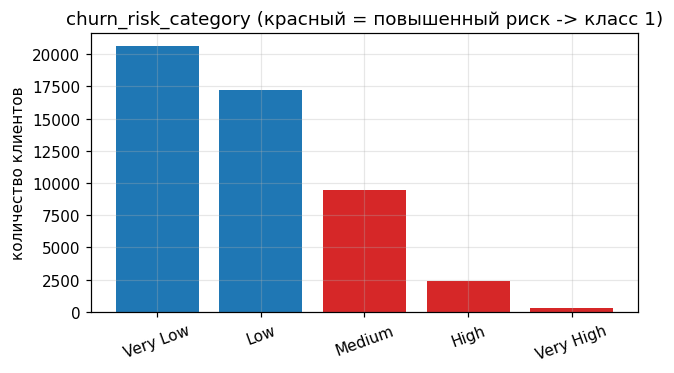

In [16]:
df_raw = load_raw()
print("Размер датасета:", df_raw.shape)

counts = df_raw[TARGET_COL].value_counts()
fig, ax = plt.subplots(figsize=(6, 3.5))
colors = ["tab:red" if c in HIGH_RISK_CATEGORIES else "tab:blue" for c in counts.index]
ax.bar(counts.index, counts.values, color=colors)
ax.set_ylabel("количество клиентов")
ax.set_title("churn_risk_category (красный = повышенный риск -> класс 1)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [17]:
X_train, X_test, y_train, y_test, preprocessor = load_dataset()

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Доля класса 1 (высокий риск) train: {(y_train == 1).mean():.3f}, test: {(y_test == 1).mean():.3f}")
print(f"Число признаков после OneHot/StandardScaler: {X_train.shape[1]}")

X_train: (40000, 64), X_test: (10000, 64)
Доля класса 1 (высокий риск) train: 0.244, test: 0.244
Число признаков после OneHot/StandardScaler: 64


## PCA-проекция классов

Проекция признаков на первые 2 главные компоненты, точки раскрашены по классу.

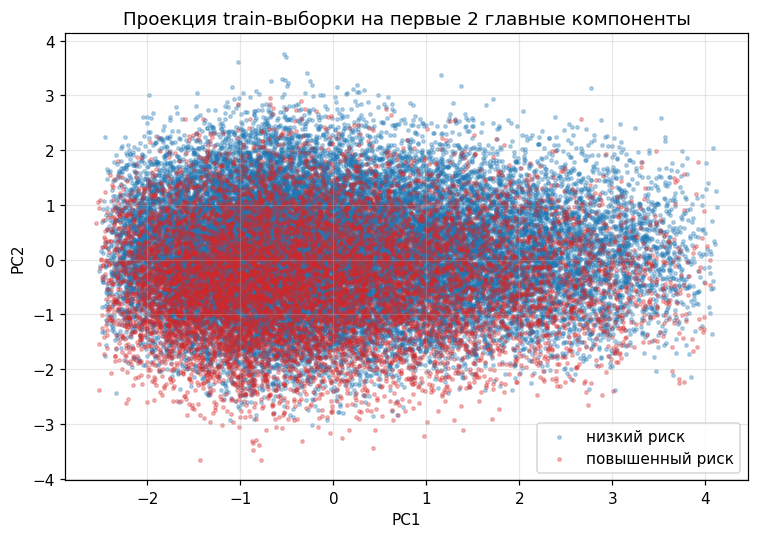

Объяснённая дисперсия: PC1=0.102, PC2=0.054, сумма=0.156


In [18]:
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train)

fig, ax = plt.subplots(figsize=(7, 5))
for cls, color, label in [(-1.0, "tab:blue", "низкий риск"), (1.0, "tab:red", "повышенный риск")]:
    mask = y_train == cls
    ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1], s=5, alpha=0.3, color=color, label=label)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Проекция train-выборки на первые 2 главные компоненты")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Объяснённая дисперсия: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}, сумма={pca.explained_variance_ratio_.sum():.3f}")

Классы визуально перемешаны, объяснённая дисперсия первых двух компонент — 15.6%.

## Этап 1. Отступ объекта (п.2)

Гистограммы отступов до и после обучения.

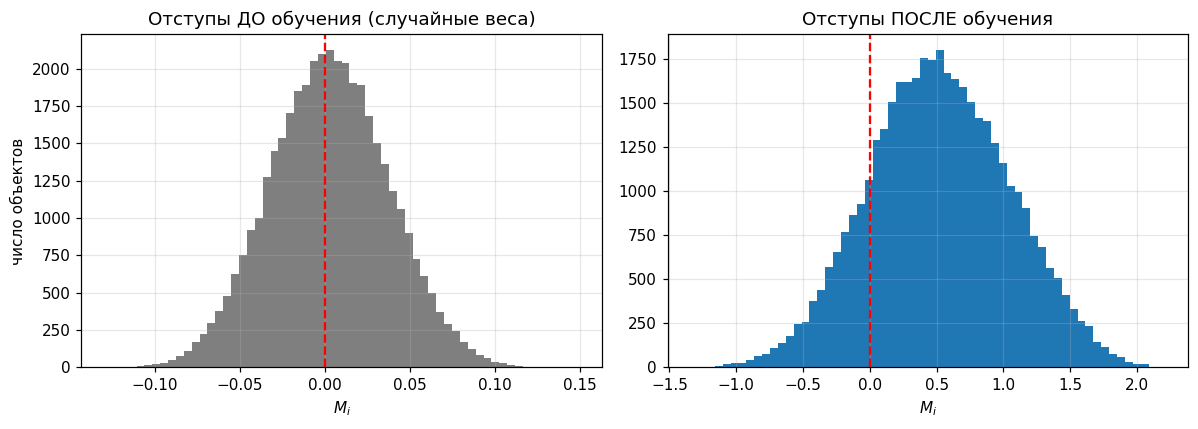

Доля объектов с M<0 ДО обучения:    0.468  (случайные веса ~ угадывание)
Доля объектов с M<0 ПОСЛЕ обучения:  0.162  (это и есть доля ошибок классификации)
Доля пограничных объектов |M|<0.5:   0.466  (близко к границе, 'трудные' объекты)


In [19]:
d = X_train.shape[1]
rng = np.random.default_rng(0)
w_random = rng.normal(scale=0.01, size=d + 1)
M_before = margin(w_random, X_train, y_train)

clf_demo = LinearClassifier(
    init="correlation", step_strategy="fixed", sampling_strategy="uniform",
    eta=0.005, gamma=0.9, l2_lambda=1e-2, max_iter=20000, random_state=42,
)
clf_demo.fit(X_train, y_train)
M_after = clf_demo.margin(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(M_before, bins=60, color="tab:gray")
axes[0].axvline(0, color="red", ls="--")
axes[0].set_title("Отступы ДО обучения (случайные веса)")
axes[0].set_xlabel("$M_i$"); axes[0].set_ylabel("число объектов")

axes[1].hist(M_after, bins=60, color="tab:blue")
axes[1].axvline(0, color="red", ls="--")
axes[1].set_title("Отступы ПОСЛЕ обучения")
axes[1].set_xlabel("$M_i$")
plt.tight_layout()
plt.show()

share_neg_before = (M_before < 0).mean()
share_neg_after = (M_after < 0).mean()
share_border_after = (np.abs(M_after) < 0.5).mean()
print(f"Доля объектов с M<0 ДО обучения:    {share_neg_before:.3f}  (случайные веса ~ угадывание)")
print(f"Доля объектов с M<0 ПОСЛЕ обучения:  {share_neg_after:.3f}  (это и есть доля ошибок классификации)")
print(f"Доля пограничных объектов |M|<0.5:   {share_border_after:.3f}  (близко к границе, 'трудные' объекты)")

Доля ошибок падает с 0.468 до 0.162 после обучения.

## Этап 2. Функция потерь и градиент (п.3)

Квадратичная функция потерь и её градиент — loss, loss_grad.

## Этап 3. Рекуррентная оценка функционала качества (п.4)

Q — скользящее среднее ошибки, используется для графиков сходимости.

## Этап 4–5. SGD с инерцией (momentum) и L2-регуляризация (п.5, п.6)

Сравнение l2_lambda=0 и l2_lambda=5.0: норма весов, сходимость Q, train/test loss.

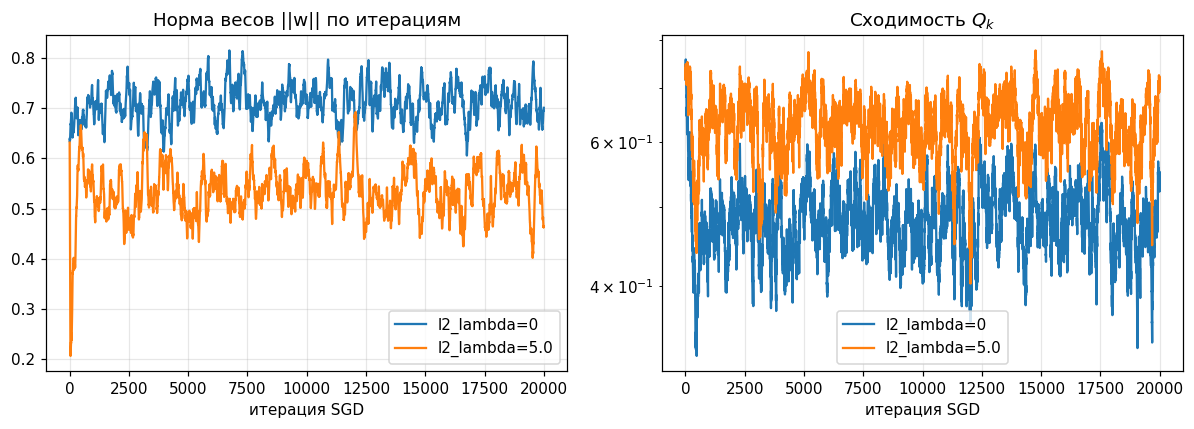

 l2_lambda |    ||w|| |  train loss |  test loss
       0.0 |    0.701 |      0.5073 |     0.5066
       5.0 |    0.465 |      0.6485 |     0.6477


In [21]:
clf_l2_0 = LinearClassifier(init="correlation", step_strategy="fixed", sampling_strategy="uniform",
                            eta=0.005, gamma=0.9, l2_lambda=0.0, max_iter=20000, random_state=42)
clf_l2_0.fit(X_train, y_train)

clf_l2_big = LinearClassifier(init="correlation", step_strategy="fixed", sampling_strategy="uniform",
                               eta=0.005, gamma=0.9, l2_lambda=5.0, max_iter=20000, random_state=42)
clf_l2_big.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(clf_l2_0.history_.w_norm, label="l2_lambda=0")
axes[0].plot(clf_l2_big.history_.w_norm, label="l2_lambda=5.0")
axes[0].set_title("Норма весов ||w|| по итерациям")
axes[0].set_xlabel("итерация SGD"); axes[0].legend()

axes[1].plot(clf_l2_0.history_.Q, label="l2_lambda=0")
axes[1].plot(clf_l2_big.history_.Q, label="l2_lambda=5.0")
axes[1].set_yscale("log")
axes[1].set_title("Сходимость $Q_k$")
axes[1].set_xlabel("итерация SGD"); axes[1].legend()
plt.tight_layout()
plt.show()

print(f"{'l2_lambda':>10} | {'||w||':>8} | {'train loss':>11} | {'test loss':>10}")
for name, clf in [("0.0", clf_l2_0), ("5.0", clf_l2_big)]:
    M_tr = clf.margin(X_train, y_train)
    M_te = clf.margin(X_test, y_test)
    print(f"{name:>10} | {np.linalg.norm(clf.w_):8.3f} | {loss(M_tr).mean():11.4f} | {loss(M_te).mean():10.4f}")

С ростом l2_lambda норма весов падает, train и test loss почти совпадают — переобучения нет.

## Этап 6. Скорейший градиентный спуск (п.7)

Сравнение шага fixed и steepest.

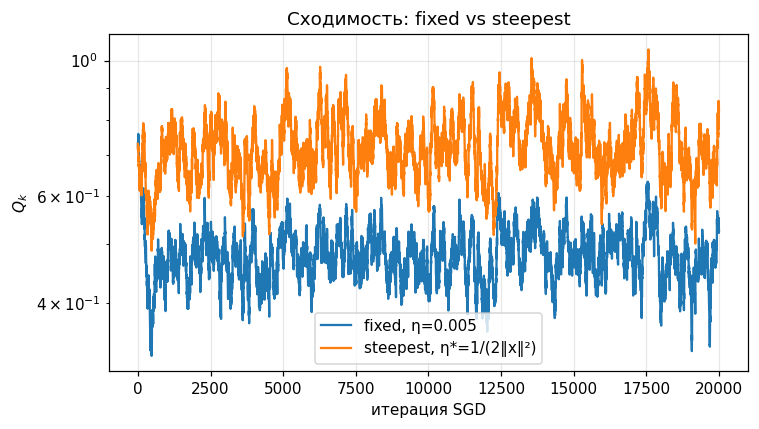

,accuracy,precision,recall,f1,roc_auc
fixed,0.8354,0.670391,0.639606,0.654637,0.881218
steepest,0.7205,0.438065,0.516195,0.473932,0.728353


In [22]:
common = dict(init="correlation", sampling_strategy="uniform", gamma=0.9, l2_lambda=1e-2,
              max_iter=20000, random_state=42)

clf_fixed = LinearClassifier(step_strategy="fixed", eta=0.005, **common)
clf_fixed.fit(X_train, y_train)

clf_steep = LinearClassifier(step_strategy="steepest", **common)
clf_steep.fit(X_train, y_train)

plt.figure(figsize=(7, 4))
plt.plot(clf_fixed.history_.Q, label="fixed, η=0.005")
plt.plot(clf_steep.history_.Q, label="steepest, η*=1/(2‖x‖²)")
plt.yscale("log")
plt.xlabel("итерация SGD"); plt.ylabel("$Q_k$")
plt.title("Сходимость: fixed vs steepest")
plt.legend()
plt.tight_layout()
plt.show()

res_step = {
    "fixed": evaluate_classifier(clf_fixed, X_test, y_test),
    "steepest": evaluate_classifier(clf_steep, X_test, y_test),
}
results_table(res_step)

fixed сходится лучше steepest на этой задаче.

In [23]:
# доп. проверка формулы η* на конкретном объекте
i = 0
n = X_train.shape[0]
X_aug = np.hstack([X_train, np.ones((n, 1))])
x_i = X_aug[i]
eta_star = LinearClassifier.steepest_eta(x_i)
w0 = np.zeros(x_i.shape[0])
grad0 = loss_grad(w0, x_i, y_train[i])
w1 = w0 - eta_star * grad0
M1 = y_train[i] * (x_i @ w1)
print(f"eta* = {eta_star:.5f}, отступ после шага M1 = {M1:.6f}  (должен быть ≈ 1.0)")

eta* = 0.02492, отступ после шага M1 = 1.000000  (должен быть ≈ 1.0)


## Этап 7. Предъявление объектов по модулю отступа (п.8)

Сравнение uniform и margin сэмплирования.

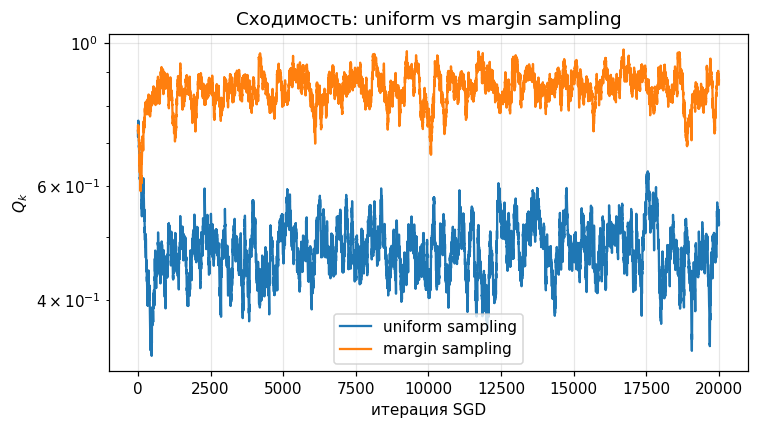

,accuracy,precision,recall,f1,roc_auc
margin,0.8437,0.694494,0.641246,0.666809,0.898073
uniform,0.8354,0.670391,0.639606,0.654637,0.881218


In [24]:
common2 = dict(init="correlation", step_strategy="fixed", eta=0.005, gamma=0.9, l2_lambda=1e-2,
               max_iter=20000, margin_recompute_every=100, random_state=42)

clf_unif = LinearClassifier(sampling_strategy="uniform", **common2)
clf_unif.fit(X_train, y_train)

clf_marg = LinearClassifier(sampling_strategy="margin", **common2)
clf_marg.fit(X_train, y_train)

plt.figure(figsize=(7, 4))
plt.plot(clf_unif.history_.Q, label="uniform sampling")
plt.plot(clf_marg.history_.Q, label="margin sampling")
plt.yscale("log")
plt.xlabel("итерация SGD"); plt.ylabel("$Q_k$")
plt.title("Сходимость: uniform vs margin sampling")
plt.legend()
plt.tight_layout()
plt.show()

res_sampling = {
    "uniform": evaluate_classifier(clf_unif, X_test, y_test),
    "margin": evaluate_classifier(clf_marg, X_test, y_test),
}
results_table(res_sampling)

Margin-сэмплирование даёт небольшой прирост метрик относительно uniform.

## Этап 8. Три режима обучения (п.9)

1. 9.1 — корреляционная инициализация, uniform, fixed.
2. 9.2 — случайная инициализация, мультистарт (10 стартов).
3. 9.3 — случайная инициализация, margin-сэмплирование.

In [25]:
import time

base = dict(gamma=0.9, l2_lambda=1e-2, eta=0.005, max_iter=20000,
            margin_recompute_every=100, random_state=42)

t0 = time.time()
clf_91 = LinearClassifier(init="correlation", step_strategy="fixed", sampling_strategy="uniform", **base)
clf_91.fit(X_train, y_train)
t1 = time.time()

clf_92 = LinearClassifier(init="random", n_starts=10, step_strategy="fixed", sampling_strategy="uniform", **base)
clf_92.fit(X_train, y_train)
t2 = time.time()

clf_93 = LinearClassifier(init="random", step_strategy="fixed", sampling_strategy="margin", **base)
clf_93.fit(X_train, y_train)
t3 = time.time()

modes = {
    "9.1 corr-init + uniform": clf_91,
    "9.2 random + multistart(10)": clf_92,
    "9.3 random + margin-sampling": clf_93,
}

print(f"Время обучения: 9.1={t1 - t0:.2f}s, 9.2={t2 - t1:.2f}s (10 стартов), 9.3={t3 - t2:.2f}s")
for name, clf in modes.items():
    print(f"{name:32s} n_iter={clf.history_.n_iter:6d}  Q_final={clf.history_.Q[-1]:.4f}")

Время обучения: 9.1=0.60s, 9.2=5.69s (10 стартов), 9.3=7.95s
9.1 corr-init + uniform          n_iter= 20000  Q_final=0.5273
9.2 random + multistart(10)      n_iter= 20000  Q_final=0.4120
9.3 random + margin-sampling     n_iter= 20000  Q_final=0.9000


## Этап 9. Оценка качества (п.10)

accuracy, precision, recall, F1, ROC-AUC на train и test для трёх режимов.

In [26]:
train_res = {name: evaluate_classifier(clf, X_train, y_train) for name, clf in modes.items()}
test_res = {name: evaluate_classifier(clf, X_test, y_test) for name, clf in modes.items()}

print("=== TRAIN ===")
display(results_table(train_res))
print("=== TEST ===")
display(results_table(test_res))

=== TRAIN ===


,accuracy,precision,recall,f1,roc_auc
9.2 random + multistart(10),0.846650,0.732230,0.585093,0.650444,0.895441
9.3 random + margin-sampling,0.836175,0.717135,0.541932,0.617343,0.881346
9.1 corr-init + uniform,0.837750,0.681333,0.628665,0.653940,0.879630


=== TEST ===


,accuracy,precision,recall,f1,roc_auc
9.2 random + multistart(10),0.8449,0.724924,0.586716,0.648538,0.897250
9.1 corr-init + uniform,0.8354,0.670391,0.639606,0.654637,0.881218
9.3 random + margin-sampling,0.8306,0.701243,0.532185,0.605128,0.880067


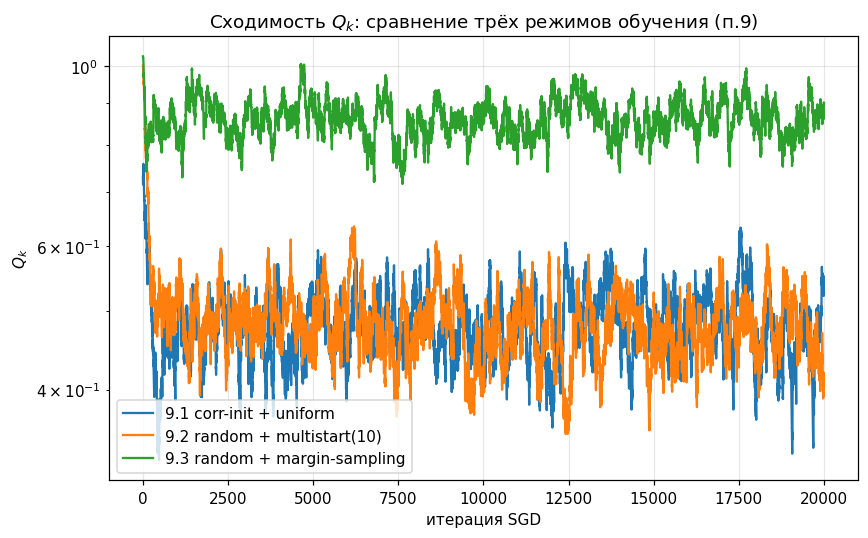

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
for name, clf in modes.items():
    ax.plot(clf.history_.Q, label=name)
ax.set_yscale("log")
ax.set_xlabel("итерация SGD")
ax.set_ylabel("$Q_k$")
ax.set_title("Сходимость $Q_k$: сравнение трёх режимов обучения (п.9)")
ax.legend()
plt.tight_layout()
plt.show()

По ROC-AUC на test: 9.2 > 9.1 > 9.3.

## Этап 10. Сравнение с эталоном (п.11)

LogisticRegression и DummyClassifier как эталоны.

In [28]:
y01_train = pm1_to_01(y_train)
y01_test = pm1_to_01(y_test)

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y01_train)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y01_train)


def eval_sklearn(model, X, y01):
    pred = model.predict(X)
    scores = model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba") else pred
    return {
        "accuracy": accuracy_score(y01, pred),
        "precision": precision_score(y01, pred, zero_division=0),
        "recall": recall_score(y01, pred, zero_division=0),
        "f1": f1_score(y01, pred, zero_division=0),
        "roc_auc": roc_auc_score(y01, scores),
    }


best_mode_name = max(test_res, key=lambda k: test_res[k]["roc_auc"])
best_clf = modes[best_mode_name]

final_results = {
    "DummyClassifier": eval_sklearn(dummy, X_test, y01_test),
    "LogisticRegression (эталон)": eval_sklearn(logreg, X_test, y01_test),
    **{f"LinearClassifier: {name}": res for name, res in test_res.items()},
}

final_table = results_table(final_results)
print(f"Лучший собственный режим: {best_mode_name}\n")
best_row_label = f"LinearClassifier: {best_mode_name}"
final_table_display = final_table.copy()
final_table_display.index = [f"-> {i} <-" if i == best_row_label else i for i in final_table_display.index]
final_table_display

Лучший собственный режим: 9.2 random + multistart(10)



,accuracy,precision,recall,f1,roc_auc
LogisticRegression (эталон),0.8544,0.740578,0.620336,0.675145,0.916562
-> LinearClassifier: 9.2 random + multistart(10) <-,0.8449,0.724924,0.586716,0.648538,0.897250
LinearClassifier: 9.1 corr-init + uniform,0.8354,0.670391,0.639606,0.654637,0.881218
LinearClassifier: 9.3 random + margin-sampling,0.8306,0.701243,0.532185,0.605128,0.880067
DummyClassifier,0.7561,0.000000,0.000000,0.000000,0.500000


Лучший режим (9.2) уступает LogisticRegression по ROC-AUC на ~0.019.

## Выводы

1. Реализован LinearClassifier: отступ, потеря и градиент, Q, SGD с инерцией, L2, steepest, margin-сэмплирование, корреляционная инициализация, мультистарт.
2. Доля ошибок падает с 0.468 до 0.162 после обучения.
3. Переобучения не наблюдается при любом l2_lambda.
4. fixed стабильнее steepest.
5. Лучший режим — 9.2, ROC-AUC ≈ 0.897.
6. Разрыв с LogisticRegression (ROC-AUC ≈ 0.917) — ~0.019.